In [1]:
import fitz
import pytesseract
from PIL import Image
import io
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, RectangleSelector
import os

class PDFProcessor:
    def __init__(self):
        self.current_page = None
        self.current_image = None
        self.crop_coords = {}
        self.output_dir = "processed_pages"
        
    def show_page(self, image, page_num):
        """Display a page with matplotlib and allow crop selection"""
        self.current_page = page_num
        self.current_image = image
        
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(image)
        
        # Add buttons
        plt.subplots_adjust(bottom=0.2)
        accept_btn_ax = plt.axes([0.7, 0.05, 0.1, 0.075])
        accept_btn = Button(accept_btn_ax, 'Accept Crop')
        
        skip_btn_ax = plt.axes([0.81, 0.05, 0.1, 0.075])
        skip_btn = Button(skip_btn_ax, 'Skip Page')
        
        def line_select_callback(eclick, erelease):
            x1, y1 = eclick.xdata, eclick.ydata
            x2, y2 = erelease.xdata, erelease.ydata
            self.crop_coords[self.current_page] = (
                min(x1, x2), min(y1, y2),
                max(x1, x2), max(y1, y2)
            )
        
        def accept(event):
            plt.close()
            
        def skip(event):
            self.crop_coords[self.current_page] = None
            plt.close()
            
        accept_btn.on_clicked(accept)
        skip_btn.on_clicked(skip)
        
        rs = RectangleSelector(
            ax, line_select_callback,
            drawtype='box', useblit=True,
            button=[1],  # left mouse button only
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True
        )
        plt.show()
        
    def process_pdf(self, pdf_path):
        """Process PDF with user interaction for cropping"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
        doc = fitz.open(pdf_path)
        all_items = []
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            pix = page.get_pixmap()
            
            # Convert PyMuPDF pixmap to PIL Image
            img_data = pix.samples
            img = Image.frombytes("RGB", [pix.width, pix.height], img_data)
            
            # Show page and get user crop selection
            print(f"\nProcessing page {page_num + 1}")
            self.show_page(img, page_num)
            
            if self.crop_coords.get(page_num) is None:
                print(f"Skipping page {page_num + 1}")
                continue
                
            # Crop image based on user selection
            x1, y1, x2, y2 = [int(coord) for coord in self.crop_coords[page_num]]
            cropped_img = img.crop((x1, y1, x2, y2))
            
            # Save cropped image
            output_path = os.path.join(self.output_dir, f'page_{page_num + 1}.png')
            cropped_img.save(output_path)
            
            # Process the cropped image
            processed_img = self.preprocess_image(cropped_img)
            
            # Perform OCR
            text = pytesseract.image_to_string(processed_img, config='--oem 3 --psm 6')
            
            # Extract and store BOM data
            items = self.extract_bom_data(text)
            all_items.extend(items)
        
        doc.close()
        return all_items
    
    @staticmethod
    def preprocess_image(image):
        """Preprocess the image to improve OCR accuracy"""
        opencv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(opencv_img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Image.fromarray(thresh)
    
    @staticmethod
    def extract_bom_data(text):
        """Extract Bill of Materials data"""
        items = []
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        
        pattern = r'(?P<id>\d+)\s*(?P<qty>[\d\'-]+)\s*(?P<location>SHOP|FIELD)\s*(?P<nd>[\d/]+\"?)\s*(?P<description>.*)'
        
        for line in lines:
            match = re.search(pattern, line)
            if match:
                items.append({
                    'id': match.group('id'),
                    'qty': match.group('qty'),
                    'location': match.group('location'),
                    'nd': match.group('nd'),
                    'description': match.group('description').strip()
                })
        
        return items

def display_results(items):
    """Display the BOM results in a table format"""
    print("\nBill of Materials:")
    print("=" * 100)
    print(f"{'ID':<5}{'QTY':<10}{'SHOP/FIELD':<12}{'ND':<8}{'DESCRIPTION':<65}")
    print("-" * 100)
    
    for item in items:
        print(f"{item['id']:<5}{item['qty']:<10}{item['location']:<12}{item['nd']:<8}{item['description']:<65}")

def main():
    pdf_path = input("Enter the path to your PDF file: ")
    
    try:
        processor = PDFProcessor()
        items = processor.process_pdf(pdf_path)
        display_results(items)
        
        print(f"\nProcessed images have been saved to the '{processor.output_dir}' directory")
        
    except Exception as e:
        print(f"Error processing PDF: {e}")

if __name__ == "__main__":
    main()


Bill of Materials:
ID   QTY       SHOP/FIELD  ND      DESCRIPTION                                                      
----------------------------------------------------------------------------------------------------

Processed images have been saved to the 'processed_pages' directory



Processing page 1
Error processing PDF: __init__() got an unexpected keyword argument 'drawtype'


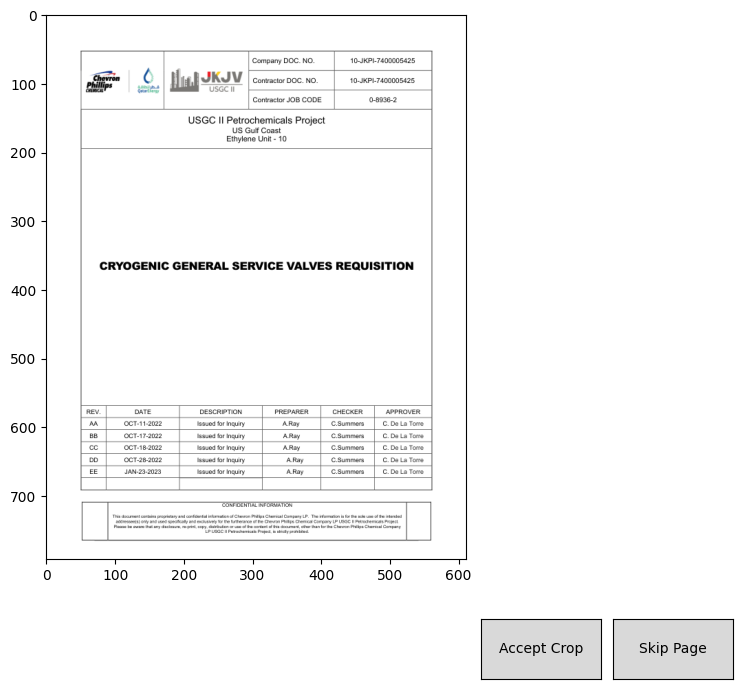

In [3]:
import fitz
import pytesseract
from PIL import Image
import io
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, RectangleSelector
import os

class PDFProcessor:
    def __init__(self):
        self.current_page = None
        self.current_image = None
        self.crop_coords = {}
        self.output_dir = "processed_pages"
        
    def show_page(self, image, page_num):
        """Display a page with matplotlib and allow crop selection"""
        self.current_page = page_num
        self.current_image = image
        
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(image)
        
        # Add buttons
        plt.subplots_adjust(bottom=0.2)
        accept_btn_ax = plt.axes([0.7, 0.05, 0.1, 0.075])
        accept_btn = Button(accept_btn_ax, 'Accept Crop')
        
        skip_btn_ax = plt.axes([0.81, 0.05, 0.1, 0.075])
        skip_btn = Button(skip_btn_ax, 'Skip Page')
        
        def line_select_callback(eclick, erelease):
            x1, y1 = eclick.xdata, eclick.ydata
            x2, y2 = erelease.xdata, erelease.ydata
            self.crop_coords[self.current_page] = (
                min(x1, x2), min(y1, y2),
                max(x1, x2), max(y1, y2)
            )
        
        def accept(event):
            plt.close()
            
        def skip(event):
            self.crop_coords[self.current_page] = None
            plt.close()
            
        accept_btn.on_clicked(accept)
        skip_btn.on_clicked(skip)
        
        rs = RectangleSelector(
            ax, line_select_callback,
            drawtype='box', useblit=True,
            button=[1],  # left mouse button only
            minspanx=5, minspany=5,
            spancoords='pixels',
            interactive=True
        )
        plt.show()
        
    def process_pdf(self, pdf_path):
        """Process PDF with user interaction for cropping"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
        doc = fitz.open(pdf_path)
        all_items = []
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            pix = page.get_pixmap()
            
            # Convert PyMuPDF pixmap to PIL Image
            img_data = pix.samples
            img = Image.frombytes("RGB", [pix.width, pix.height], img_data)
            
            # Show page and get user crop selection
            print(f"\nProcessing page {page_num + 1}")
            self.show_page(img, page_num)
            
            if self.crop_coords.get(page_num) is None:
                print(f"Skipping page {page_num + 1}")
                continue
                
            # Crop image based on user selection
            x1, y1, x2, y2 = [int(coord) for coord in self.crop_coords[page_num]]
            cropped_img = img.crop((x1, y1, x2, y2))
            
            # Save cropped image
            output_path = os.path.join(self.output_dir, f'page_{page_num + 1}.png')
            cropped_img.save(output_path)
            
            # Process the cropped image
            processed_img = self.preprocess_image(cropped_img)
            
            # Perform OCR
            text = pytesseract.image_to_string(processed_img, config='--oem 3 --psm 6')
            
            # Extract and store BOM data
            items = self.extract_bom_data(text)
            all_items.extend(items)
        
        doc.close()
        return all_items
    
    @staticmethod
    def preprocess_image(image):
        """Preprocess the image to improve OCR accuracy"""
        opencv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(opencv_img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Image.fromarray(thresh)
    
    @staticmethod
    def extract_bom_data(text):
        """Extract Bill of Materials data"""
        items = []
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        
        pattern = r'(?P<id>\d+)\s*(?P<qty>[\d\'-]+)\s*(?P<location>SHOP|FIELD)\s*(?P<nd>[\d/]+\"?)\s*(?P<description>.*)'
        
        for line in lines:
            match = re.search(pattern, line)
            if match:
                items.append({
                    'id': match.group('id'),
                    'qty': match.group('qty'),
                    'location': match.group('location'),
                    'nd': match.group('nd'),
                    'description': match.group('description').strip()
                })
        
        return items

def display_results(items):
    """Display the BOM results in a table format"""
    print("\nBill of Materials:")
    print("=" * 100)
    print(f"{'ID':<5}{'QTY':<10}{'SHOP/FIELD':<12}{'ND':<8}{'DESCRIPTION':<65}")
    print("-" * 100)
    
    for item in items:
        print(f"{item['id']:<5}{item['qty']:<10}{item['location']:<12}{item['nd']:<8}{item['description']:<65}")

def main():
    pdf_path = input("Enter the path to your PDF file: ")
    
    try:
        processor = PDFProcessor()
        items = processor.process_pdf(pdf_path)
        display_results(items)
        
        print(f"\nProcessed images have been saved to the '{processor.output_dir}' directory")
        
    except Exception as e:
        print(f"Error processing PDF: {e}")

if __name__ == "__main__":
    main()


Processing page 1


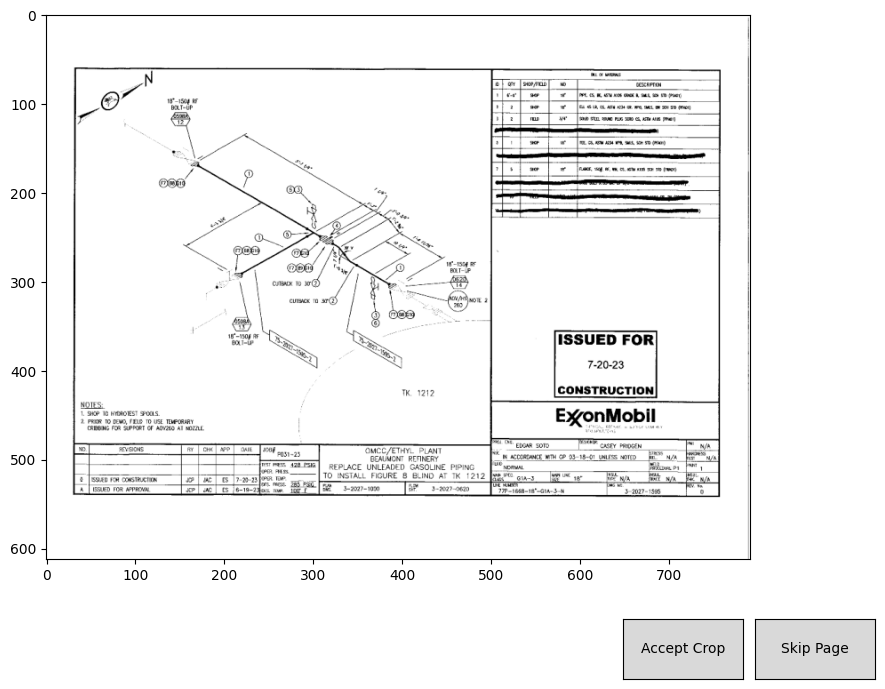

Skipping page 1

Processing page 2


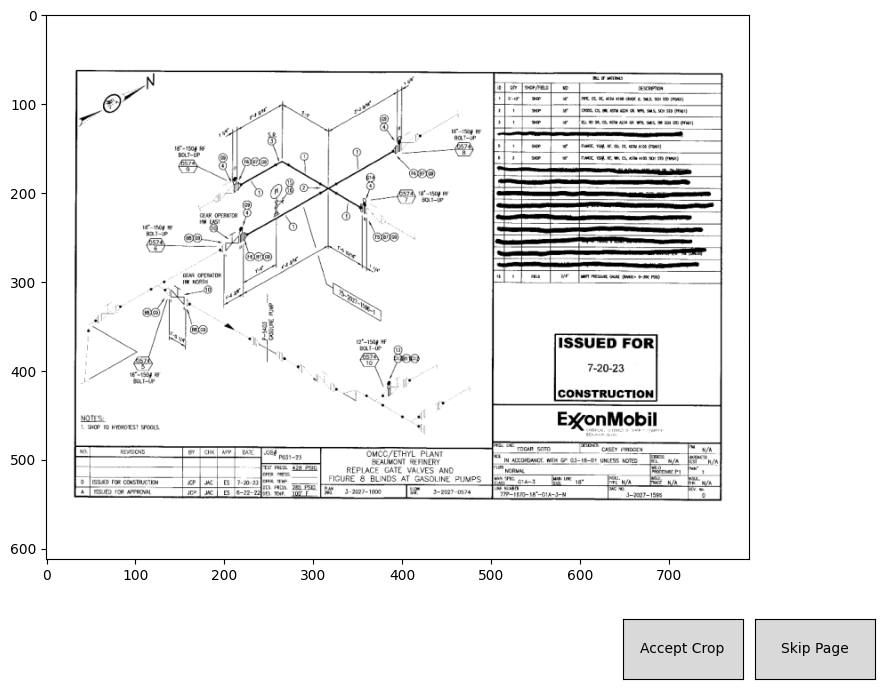

Skipping page 2

Processing page 3


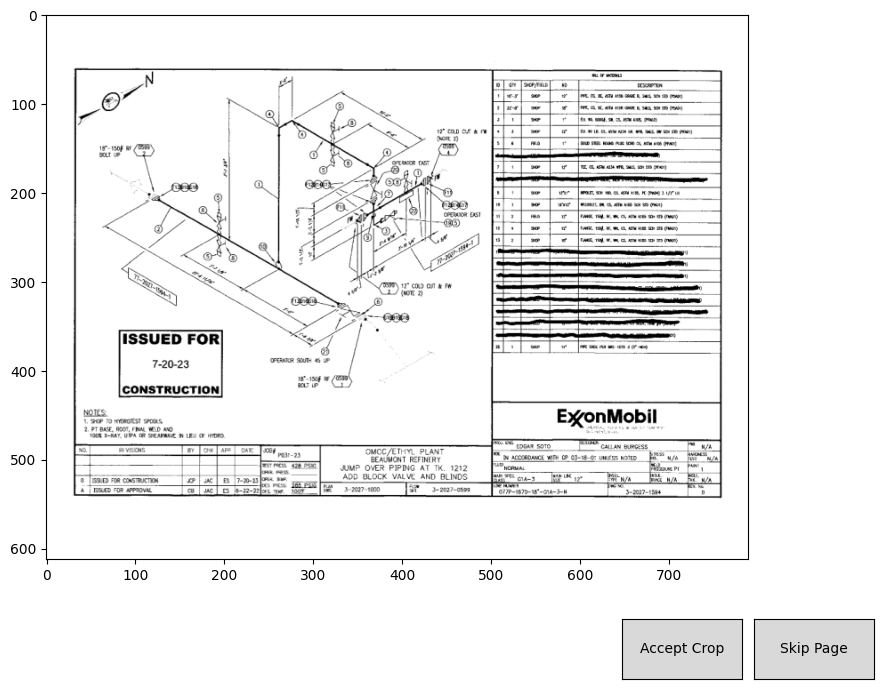

Skipping page 3

Bill of Materials:
ID   QTY       SHOP/FIELD  ND      DESCRIPTION                                                      
----------------------------------------------------------------------------------------------------

Processed images have been saved to the 'processed_pages' directory


In [5]:
import fitz
import pytesseract
from PIL import Image
import io
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, RectangleSelector
import os

class PDFProcessor:
    def __init__(self):
        self.current_page = None
        self.current_image = None
        self.crop_coords = {}
        self.output_dir = "processed_pages"
        
    def show_page(self, image, page_num):
        """Display a page with matplotlib and allow crop selection"""
        self.current_page = page_num
        self.current_image = image
        
        fig, ax = plt.subplots(figsize=(12, 8))
        ax.imshow(image)
        
        # Add buttons
        plt.subplots_adjust(bottom=0.2)
        accept_btn_ax = plt.axes([0.7, 0.05, 0.1, 0.075])
        accept_btn = Button(accept_btn_ax, 'Accept Crop')
        
        skip_btn_ax = plt.axes([0.81, 0.05, 0.1, 0.075])
        skip_btn = Button(skip_btn_ax, 'Skip Page')
        
        def line_select_callback(eclick, erelease):
            x1, y1 = eclick.xdata, eclick.ydata
            x2, y2 = erelease.xdata, erelease.ydata
            self.crop_coords[self.current_page] = (
                min(x1, x2), min(y1, y2),
                max(x1, x2), max(y1, y2)
            )
        
        def accept(event):
            plt.close()
            
        def skip(event):
            self.crop_coords[self.current_page] = None
            plt.close()
            
        accept_btn.on_clicked(accept)
        skip_btn.on_clicked(skip)
        
        rs = RectangleSelector(
            ax, line_select_callback,
            props=dict(facecolor='red', edgecolor='red', alpha=0.5, fill=True),
            interactive=True
        )
        plt.show()
        
    def process_pdf(self, pdf_path):
        """Process PDF with user interaction for cropping"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
        doc = fitz.open(pdf_path)
        all_items = []
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            pix = page.get_pixmap()
            
            # Convert PyMuPDF pixmap to PIL Image
            img_data = pix.samples
            img = Image.frombytes("RGB", [pix.width, pix.height], img_data)
            
            # Show page and get user crop selection
            print(f"\nProcessing page {page_num + 1}")
            self.show_page(img, page_num)
            
            if self.crop_coords.get(page_num) is None:
                print(f"Skipping page {page_num + 1}")
                continue
                
            # Crop image based on user selection
            x1, y1, x2, y2 = [int(coord) for coord in self.crop_coords[page_num]]
            cropped_img = img.crop((x1, y1, x2, y2))
            
            # Save cropped image
            output_path = os.path.join(self.output_dir, f'page_{page_num + 1}.png')
            cropped_img.save(output_path)
            
            # Process the cropped image
            processed_img = self.preprocess_image(cropped_img)
            
            # Perform OCR
            text = pytesseract.image_to_string(processed_img, config='--oem 3 --psm 6')
            
            # Extract and store BOM data
            items = self.extract_bom_data(text)
            all_items.extend(items)
        
        doc.close()
        return all_items
    
    @staticmethod
    def preprocess_image(image):
        """Preprocess the image to improve OCR accuracy"""
        opencv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(opencv_img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Image.fromarray(thresh)
    
    @staticmethod
    def extract_bom_data(text):
        """Extract Bill of Materials data"""
        items = []
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        
        pattern = r'(?P<id>\d+)\s*(?P<qty>[\d\'-]+)\s*(?P<location>SHOP|FIELD)\s*(?P<nd>[\d/]+\"?)\s*(?P<description>.*)'
        
        for line in lines:
            match = re.search(pattern, line)
            if match:
                items.append({
                    'id': match.group('id'),
                    'qty': match.group('qty'),
                    'location': match.group('location'),
                    'nd': match.group('nd'),
                    'description': match.group('description').strip()
                })
        
        return items

def display_results(items):
    """Display the BOM results in a table format"""
    print("\nBill of Materials:")
    print("=" * 100)
    print(f"{'ID':<5}{'QTY':<10}{'SHOP/FIELD':<12}{'ND':<8}{'DESCRIPTION':<65}")
    print("-" * 100)
    
    for item in items:
        print(f"{item['id']:<5}{item['qty']:<10}{item['location']:<12}{item['nd']:<8}{item['description']:<65}")

def main():
    pdf_path = input("Enter the path to your PDF file: ")
    
    try:
        processor = PDFProcessor()
        items = processor.process_pdf(pdf_path)
        display_results(items)
        
        print(f"\nProcessed images have been saved to the '{processor.output_dir}' directory")
        
    except Exception as e:
        print(f"Error processing PDF: {e}")

if __name__ == "__main__":
    main()


Page 1 dimensions: Width = 792, Height = 612

Processing page 1


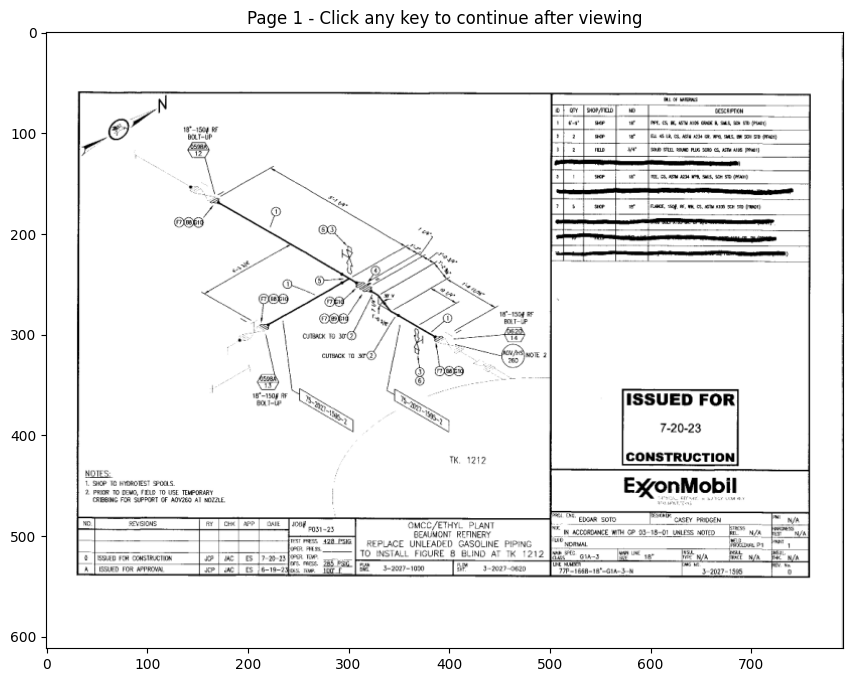


Options:
1. Enter crop coordinates
2. Skip this page

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)
Invalid coordinates format. Please try again.


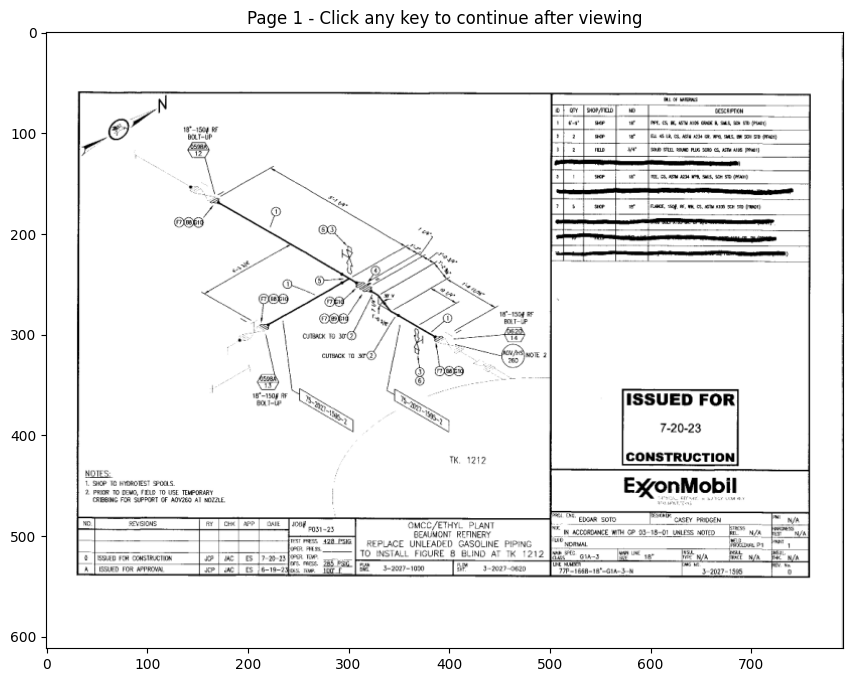


Options:
1. Enter crop coordinates
2. Skip this page


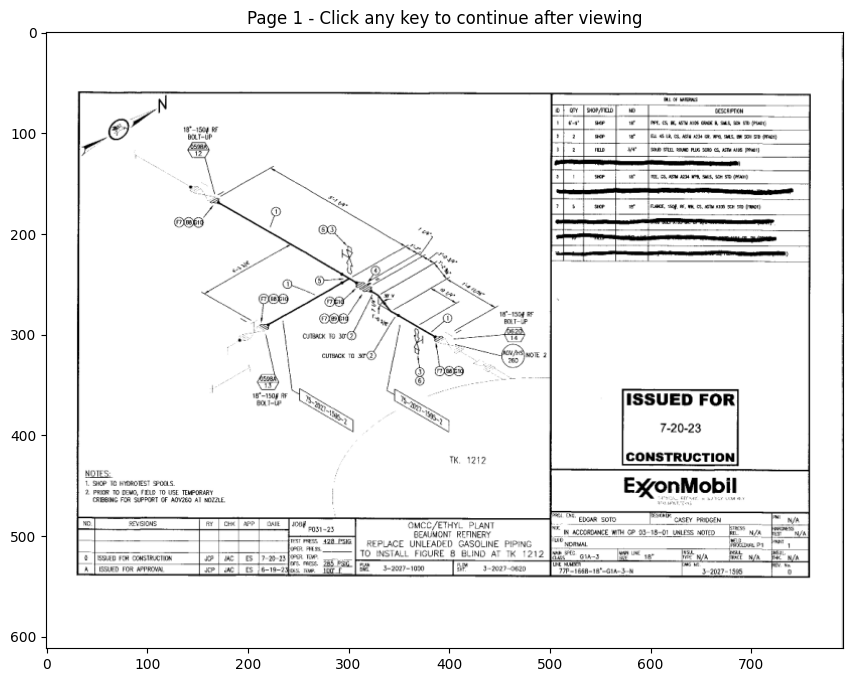


Options:
1. Enter crop coordinates
2. Skip this page

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)


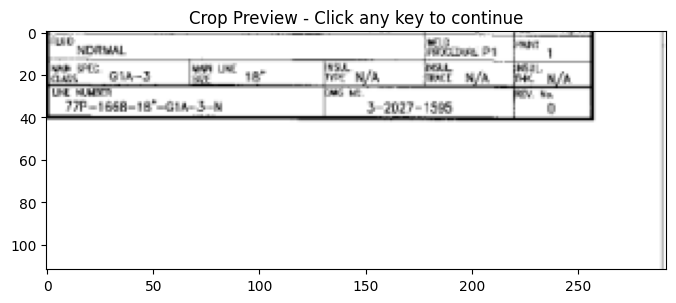


Is this crop okay?
1. Accept crop
2. Try again


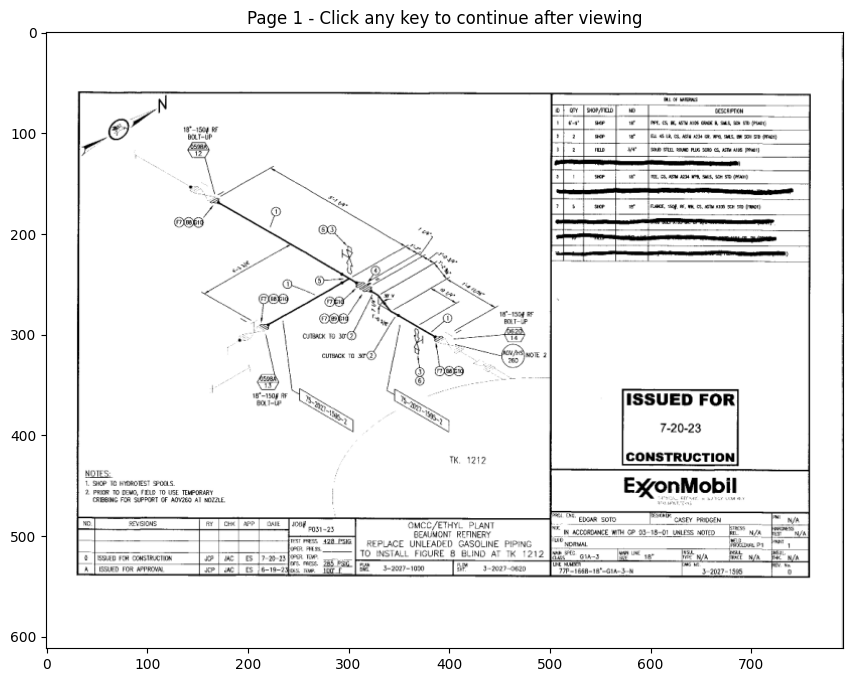


Options:
1. Enter crop coordinates
2. Skip this page


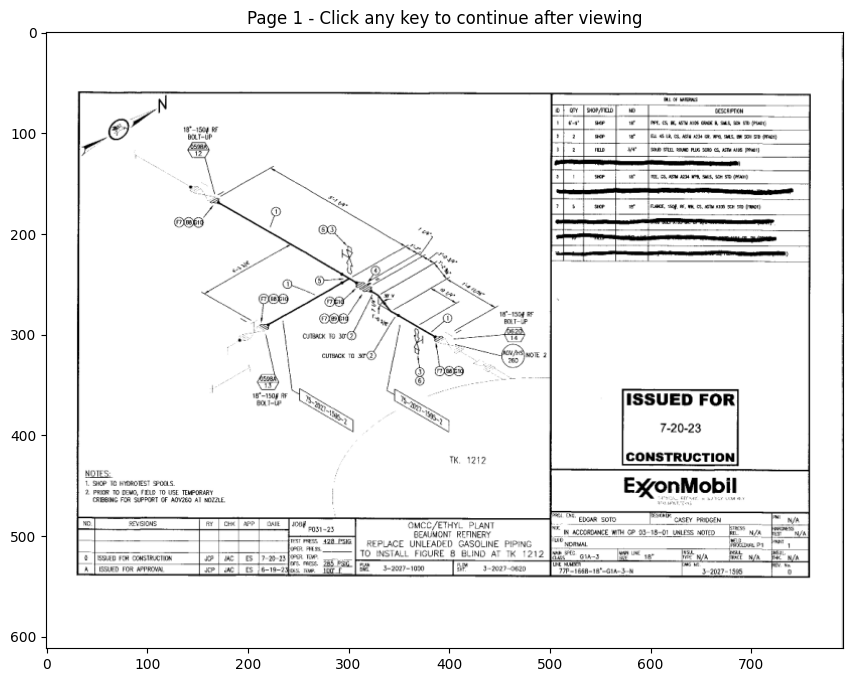


Options:
1. Enter crop coordinates
2. Skip this page

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)
Invalid coordinates format. Please try again.


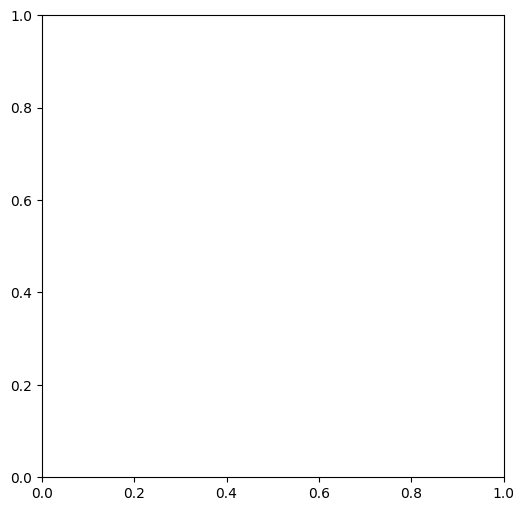

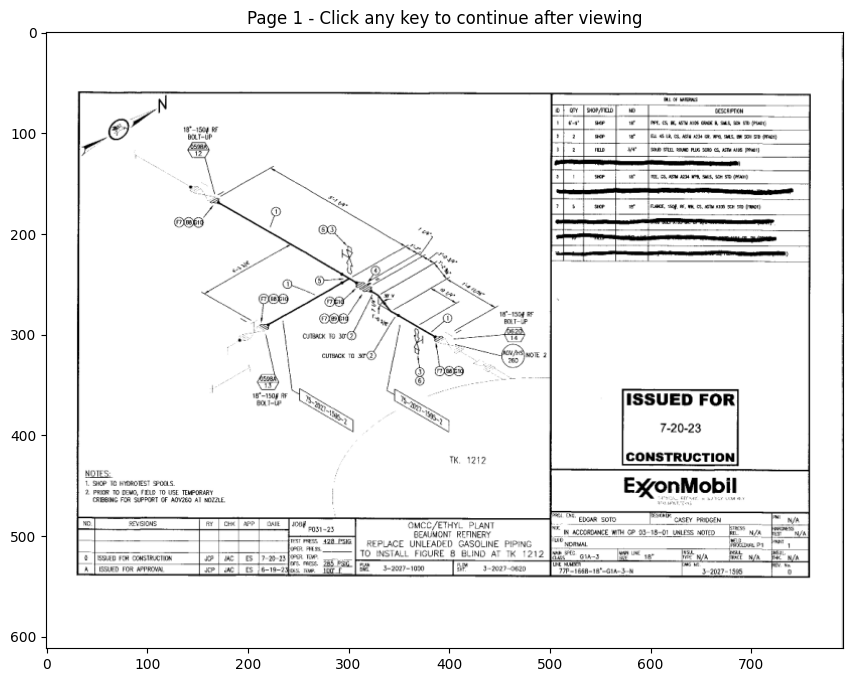


Options:
1. Enter crop coordinates
2. Skip this page


In [ ]:
import fitz
import pytesseract
from PIL import Image
import io
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
import os

class PDFProcessor:
    def __init__(self):
        self.current_page = None
        self.current_image = None
        self.crop_coords = {}
        self.output_dir = "processed_pages"
        
    def show_page(self, image, page_num):
        """Display a page and get user input for coordinates"""
        self.current_page = page_num
        self.current_image = image
        
        while True:
            # Display the image
            plt.figure(figsize=(12, 8))
            plt.imshow(image)
            plt.title(f"Page {page_num + 1} - Click any key to continue after viewing")
            plt.show()

            print("\nOptions:")
            print("1. Enter crop coordinates")
            print("2. Skip this page")
            choice = input("Enter your choice (1 or 2): ")

            if choice == "2":
                self.crop_coords[self.current_page] = None
                print(f"Skipping page {page_num + 1}")
                break
            elif choice == "1":
                try:
                    print("\nEnter coordinates for cropping:")
                    print("Format: x1,y1,x2,y2 (top-left and bottom-right corners)")
                    coords_input = input("Coordinates: ")
                    x1, y1, x2, y2 = map(int, coords_input.split(','))
                    
                    # Ensure coordinates are within image bounds
                    width, height = image.size
                    x1 = max(0, min(x1, width))
                    x2 = max(0, min(x2, width))
                    y1 = max(0, min(y1, height))
                    y2 = max(0, min(y2, height))
                    
                    # Show crop preview
                    cropped_preview = image.crop((x1, y1, x2, y2))
                    plt.figure(figsize=(8, 6))
                    plt.imshow(cropped_preview)
                    plt.title("Crop Preview - Click any key to continue")
                    plt.show()
                    
                    print("\nIs this crop okay?")
                    print("1. Accept crop")
                    print("2. Try again")
                    confirm = input("Enter your choice (1 or 2): ")
                    
                    if confirm == "1":
                        self.crop_coords[self.current_page] = (x1, y1, x2, y2)
                        break
                    # If not confirmed, loop continues
                    
                except ValueError:
                    print("Invalid coordinates format. Please try again.")
                    continue
                
    def process_pdf(self, pdf_path):
        """Process PDF with user interaction for cropping"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
        doc = fitz.open(pdf_path)
        all_items = []
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            pix = page.get_pixmap()
            
            # Convert PyMuPDF pixmap to PIL Image
            img_data = pix.samples
            img = Image.frombytes("RGB", [pix.width, pix.height], img_data)
            
            # Show page dimensions to help with coordinate selection
            width, height = img.size
            print(f"\nPage {page_num + 1} dimensions: Width = {width}, Height = {height}")
            
            # Show page and get user crop selection
            print(f"\nProcessing page {page_num + 1}")
            self.show_page(img, page_num)
            
            if self.crop_coords.get(page_num) is None:
                print(f"Skipping page {page_num + 1}")
                continue
                
            # Crop image based on user selection
            x1, y1, x2, y2 = self.crop_coords[page_num]
            cropped_img = img.crop((x1, y1, x2, y2))
            
            # Save cropped image
            output_path = os.path.join(self.output_dir, f'page_{page_num + 1}.png')
            cropped_img.save(output_path)
            print(f"Saved cropped image to: {output_path}")
            
            # Process the cropped image
            processed_img = self.preprocess_image(cropped_img)
            
            # Perform OCR
            text = pytesseract.image_to_string(processed_img, config='--oem 3 --psm 6')
            
            # Extract and store BOM data
            items = self.extract_bom_data(text)
            all_items.extend(items)
        
        doc.close()
        return all_items
    
    @staticmethod
    def preprocess_image(image):
        """Preprocess the image to improve OCR accuracy"""
        opencv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(opencv_img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Image.fromarray(thresh)
    
    @staticmethod
    def extract_bom_data(text):
        """Extract Bill of Materials data"""
        items = []
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        
        pattern = r'(?P<id>\d+)\s*(?P<qty>[\d\'-]+)\s*(?P<location>SHOP|FIELD)\s*(?P<nd>[\d/]+\"?)\s*(?P<description>.*)'
        
        for line in lines:
            match = re.search(pattern, line)
            if match:
                items.append({
                    'id': match.group('id'),
                    'qty': match.group('qty'),
                    'location': match.group('location'),
                    'nd': match.group('nd'),
                    'description': match.group('description').strip()
                })
        
        return items

def display_results(items):
    """Display the BOM results in a table format"""
    print("\nBill of Materials:")
    print("=" * 100)
    print(f"{'ID':<5}{'QTY':<10}{'SHOP/FIELD':<12}{'ND':<8}{'DESCRIPTION':<65}")
    print("-" * 100)
    
    for item in items:
        print(f"{item['id']:<5}{item['qty']:<10}{item['location']:<12}{item['nd']:<8}{item['description']:<65}")

def main():
    pdf_path = input("Enter the path to your PDF file: ")
    
    try:
        processor = PDFProcessor()
        items = processor.process_pdf(pdf_path)
        display_results(items)
        
        print(f"\nProcessed images have been saved to the '{processor.output_dir}' directory")
        
    except Exception as e:
        print(f"Error processing PDF: {e}")

if __name__ == "__main__":
    main()

/Users/rc/Desktop/pdf/pdf-examples/Takeoff Drawing Example 2.pdf


Processing page 1


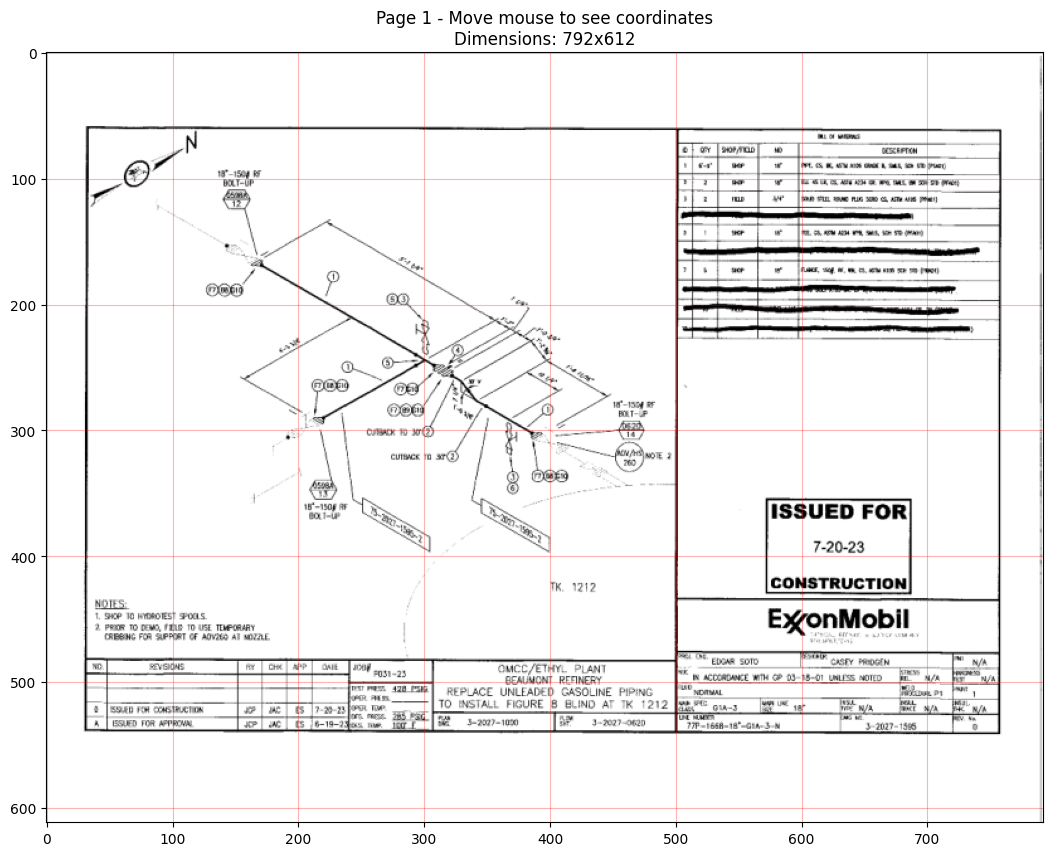


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)
Invalid coordinates format. Please try again.


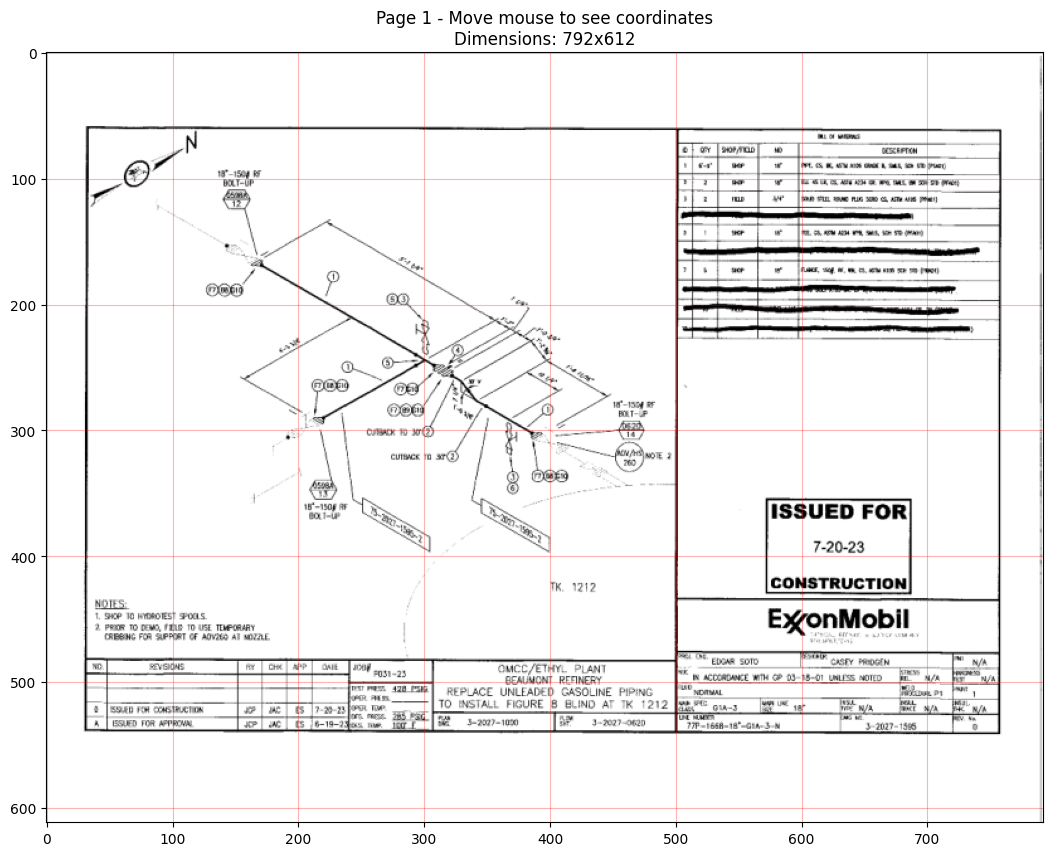


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again


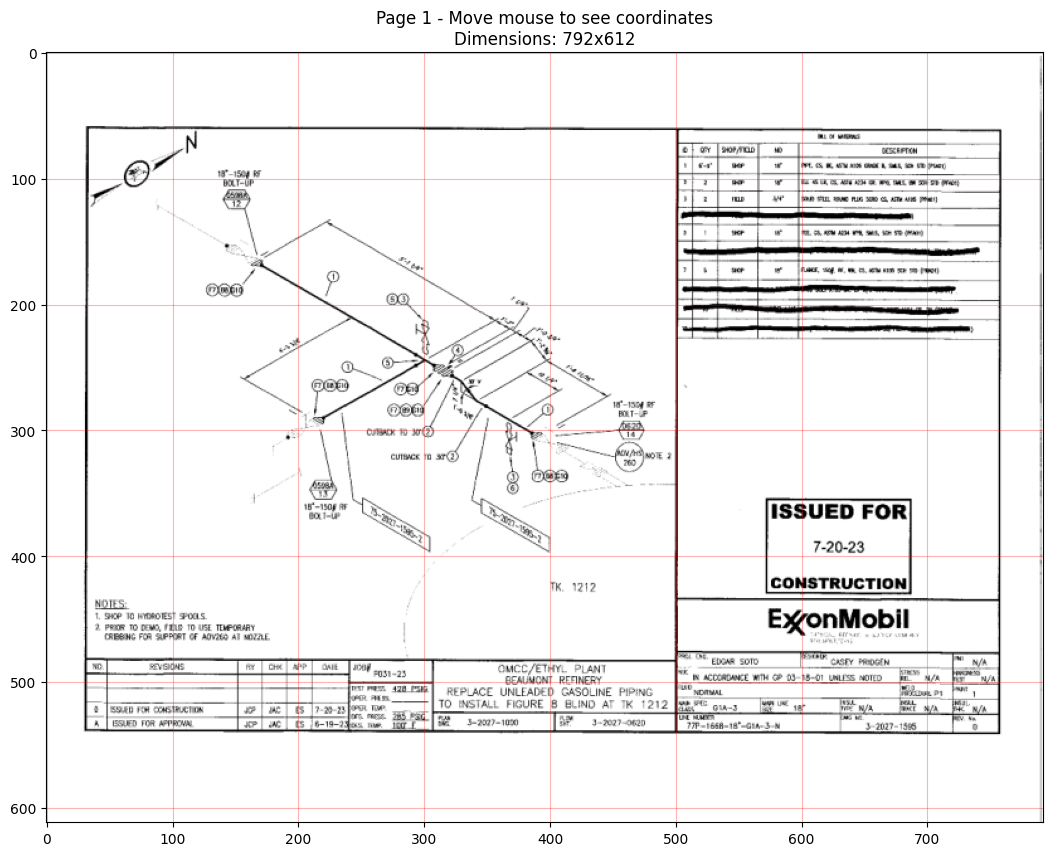


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again


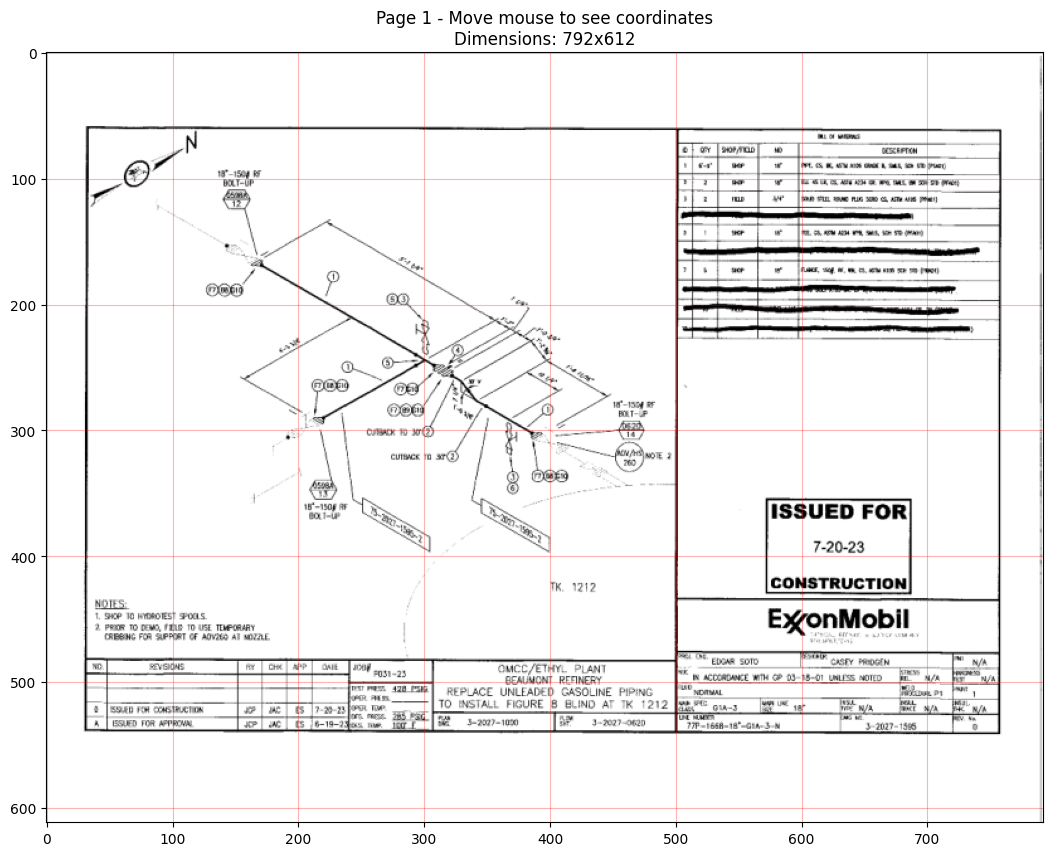


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again


In [ ]:
import fitz
import pytesseract
from PIL import Image
import io
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
import os

class PDFProcessor:
    def __init__(self):
        self.current_page = None
        self.current_image = None
        self.crop_coords = {}
        self.output_dir = "processed_pages"
        
    def show_page_with_grid(self, image, page_num):
        """Display a page with grid overlay and coordinate tracking"""
        self.current_page = page_num
        self.current_image = image
        
        width, height = image.size
        
        while True:
            # Create figure and plot image
            fig, ax = plt.subplots(figsize=(15, 10))
            ax.imshow(image)
            
            # Add grid
            ax.grid(True, color='red', alpha=0.3)
            
            # Add major grid lines every 100 pixels
            major_x_ticks = np.arange(0, width, 100)
            major_y_ticks = np.arange(0, height, 100)
            ax.set_xticks(major_x_ticks)
            ax.set_yticks(major_y_ticks)
            
            # Add labels
            plt.title(f"Page {page_num + 1} - Move mouse to see coordinates\nDimensions: {width}x{height}")
            
            # Add coordinate display
            coord_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                               bbox=dict(facecolor='white', alpha=0.8),
                               verticalalignment='top')
            
            def mouse_move(event):
                if event.inaxes:
                    x, y = int(event.xdata), int(event.ydata)
                    coord_text.set_text(f'Coordinates: x={x}, y={y}')
                    plt.draw()
            
            fig.canvas.mpl_connect('motion_notify_event', mouse_move)
            
            plt.show()
            
            print("\nOptions:")
            print("1. Enter crop coordinates")
            print("2. Skip this page")
            print("3. Show grid view again")
            choice = input("Enter your choice (1, 2, or 3): ")
            
            if choice == "2":
                self.crop_coords[self.current_page] = None
                print(f"Skipping page {page_num + 1}")
                break
            elif choice == "3":
                continue
            elif choice == "1":
                try:
                    print("\nEnter coordinates for cropping:")
                    print("Format: x1,y1,x2,y2 (top-left and bottom-right corners)")
                    coords_input = input("Coordinates: ")
                    x1, y1, x2, y2 = map(int, coords_input.split(','))
                    
                    # Ensure coordinates are within image bounds
                    x1 = max(0, min(x1, width))
                    x2 = max(0, min(x2, width))
                    y1 = max(0, min(y1, height))
                    y2 = max(0, min(y2, height))
                    
                    # Show crop preview
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Show full image with crop rectangle
                    ax1.imshow(image)
                    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red')
                    ax1.add_patch(rect)
                    ax1.set_title("Full Page with Crop Area")
                    
                    # Show cropped preview
                    cropped_preview = image.crop((x1, y1, x2, y2))
                    ax2.imshow(cropped_preview)
                    ax2.set_title("Cropped Preview")
                    
                    plt.show()
                    
                    print("\nIs this crop okay?")
                    print("1. Accept crop")
                    print("2. Try again")
                    confirm = input("Enter your choice (1 or 2): ")
                    
                    if confirm == "1":
                        self.crop_coords[self.current_page] = (x1, y1, x2, y2)
                        break
                    
                except ValueError:
                    print("Invalid coordinates format. Please try again.")
                    continue
                
    def process_pdf(self, pdf_path):
        """Process PDF with user interaction for cropping"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
        doc = fitz.open(pdf_path)
        all_items = []
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            pix = page.get_pixmap()
            
            # Convert PyMuPDF pixmap to PIL Image
            img_data = pix.samples
            img = Image.frombytes("RGB", [pix.width, pix.height], img_data)
            
            # Show page and get user crop selection
            print(f"\nProcessing page {page_num + 1}")
            self.show_page_with_grid(img, page_num)
            
            if self.crop_coords.get(page_num) is None:
                print(f"Skipping page {page_num + 1}")
                continue
                
            # Crop image based on user selection
            x1, y1, x2, y2 = self.crop_coords[page_num]
            cropped_img = img.crop((x1, y1, x2, y2))
            
            # Save cropped image
            output_path = os.path.join(self.output_dir, f'page_{page_num + 1}.png')
            cropped_img.save(output_path)
            print(f"Saved cropped image to: {output_path}")
            
            # Process the cropped image
            processed_img = self.preprocess_image(cropped_img)
            
            # Perform OCR
            text = pytesseract.image_to_string(processed_img, config='--oem 3 --psm 6')
            
            # Extract and store BOM data
            items = self.extract_bom_data(text)
            all_items.extend(items)
        
        doc.close()
        return all_items
    
    @staticmethod
    def preprocess_image(image):
        """Preprocess the image to improve OCR accuracy"""
        opencv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(opencv_img, cv2.COLOR_BGR2GRAY)
        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return Image.fromarray(thresh)
    
    @staticmethod
    def extract_bom_data(text):
        """Extract Bill of Materials data"""
        items = []
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        
        pattern = r'(?P<id>\d+)\s*(?P<qty>[\d\'-]+)\s*(?P<location>SHOP|FIELD)\s*(?P<nd>[\d/]+\"?)\s*(?P<description>.*)'
        
        for line in lines:
            match = re.search(pattern, line)
            if match:
                items.append({
                    'id': match.group('id'),
                    'qty': match.group('qty'),
                    'location': match.group('location'),
                    'nd': match.group('nd'),
                    'description': match.group('description').strip()
                })
        
        return items

def display_results(items):
    """Display the BOM results in a table format"""
    print("\nBill of Materials:")
    print("=" * 100)
    print(f"{'ID':<5}{'QTY':<10}{'SHOP/FIELD':<12}{'ND':<8}{'DESCRIPTION':<65}")
    print("-" * 100)
    
    for item in items:
        print(f"{item['id']:<5}{item['qty']:<10}{item['location']:<12}{item['nd']:<8}{item['description']:<65}")

def main():
    pdf_path = input("Enter the path to your PDF file: ")
    
    try:
        processor = PDFProcessor()
        items = processor.process_pdf(pdf_path)
        display_results(items)
        
        print(f"\nProcessed images have been saved to the '{processor.output_dir}' directory")
        
    except Exception as e:
        print(f"Error processing PDF: {e}")

if __name__ == "__main__":
    main()

In [4]:
from PIL import Image
import pytesseract

# Path to the image
image_path = "/Users/rc/Desktop/pdf/processed_pages/page_1.png"

# Open the image
image = Image.open(image_path)

# Extract text
extracted_text = pytesseract.image_to_string(image)

# Print the extracted text
print(extracted_text)


BALL OF WATERS

SHOP /FIELD ND

[eel Gi

8
FELD ye

DESCRIPTION
PIPE. CS, BE, ASTM AIO6 GRADE B, SiS, SCH STD (PSA01)

ELL 45 LR, CS, ASTM A234 GR. WPB, SMS, EW SCH STD {PFAD1}

SOLD STEEL ROUND PLUG SCAD CS, ASTM A106 (PPADS}

J

TEE, CS, ASTM A234 WPB, SMLS, SCH STD (PFA)

Ses eee

FLANGE, 150, RF, WN, CS, ASTM AIDS SCH STD (FRADT)




PDF Bill of Materials Processor

Processing page 1


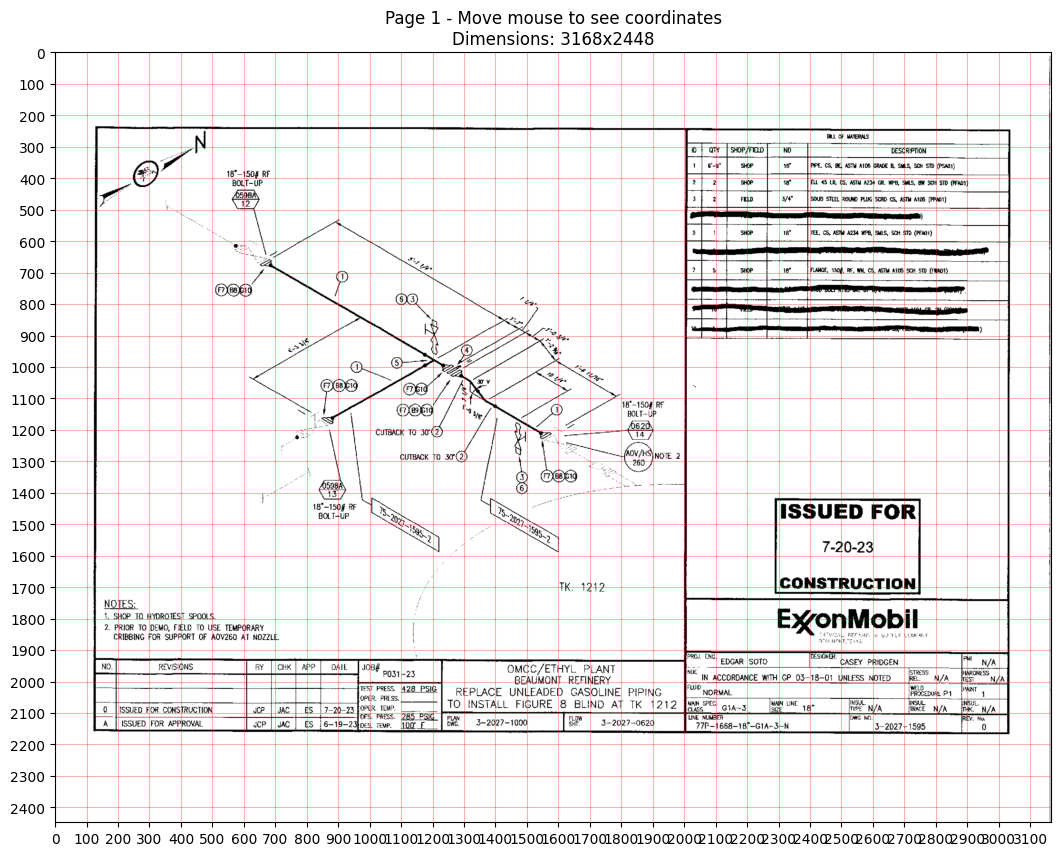


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)


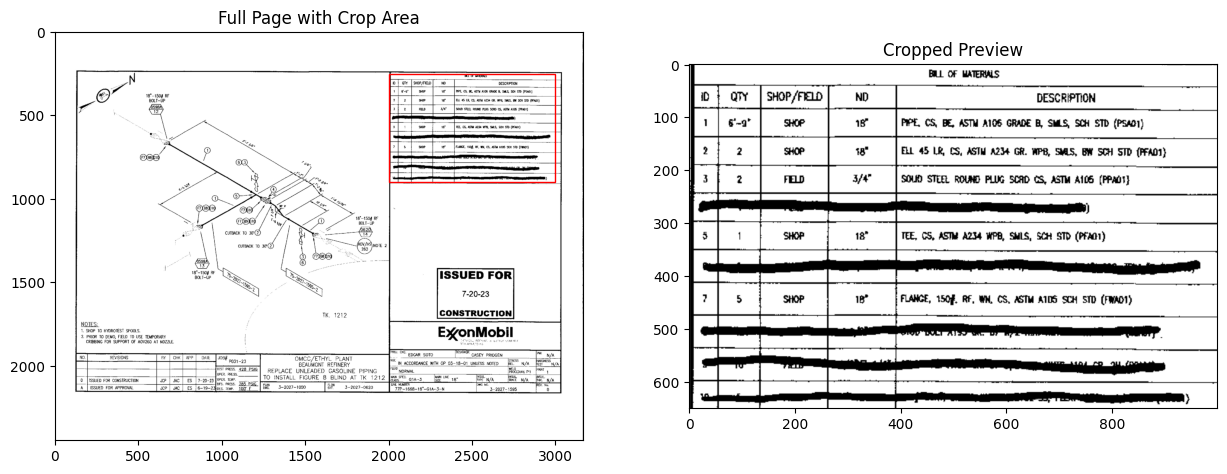


Is this crop okay?
1. Accept crop
2. Try again
Saved cropped image to: processed_pages/page_1.png

Processing page 2


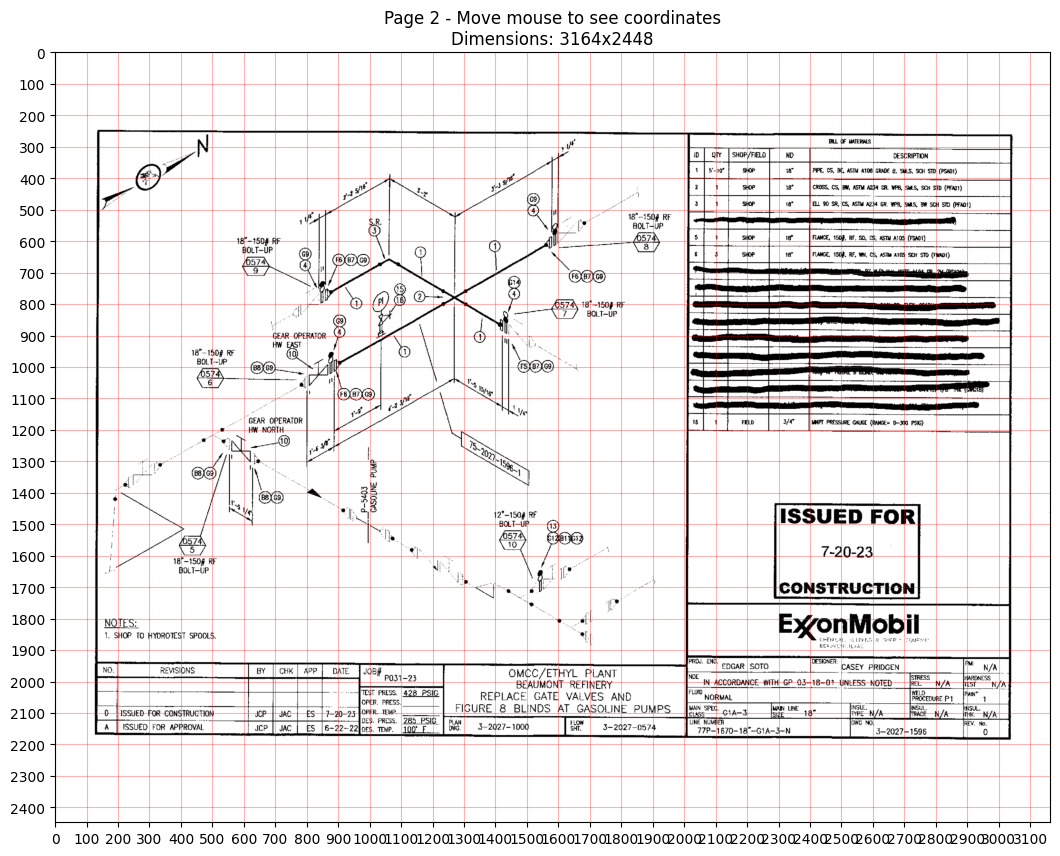


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)


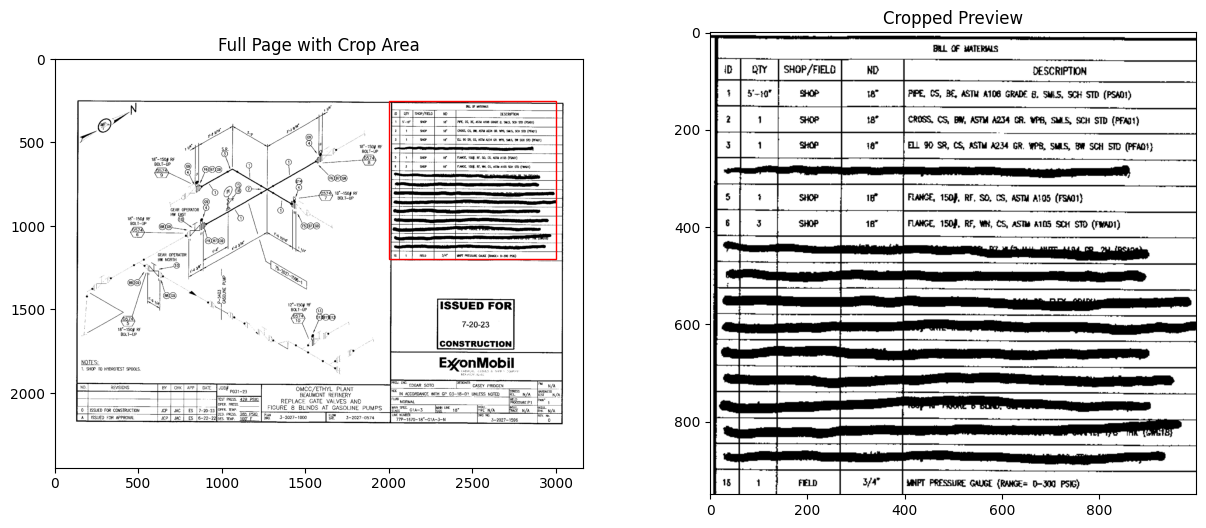


Is this crop okay?
1. Accept crop
2. Try again
Saved cropped image to: processed_pages/page_2.png

Processing page 3


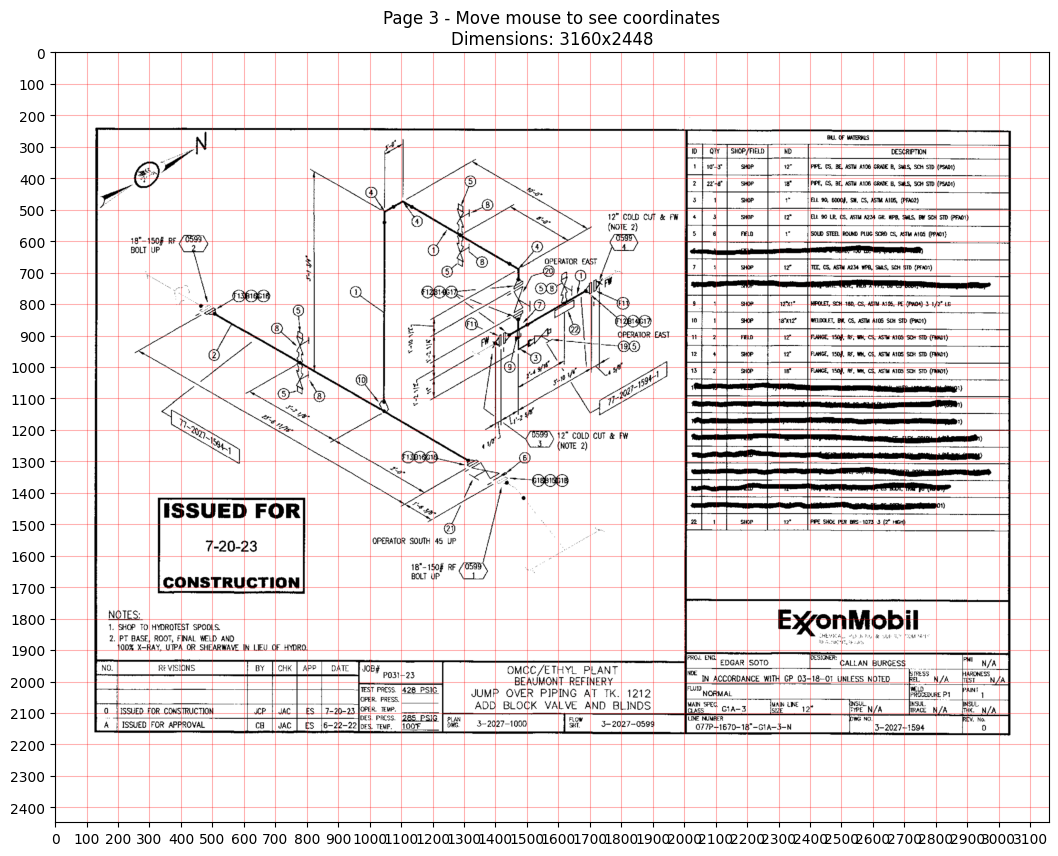


Options:
1. Enter crop coordinates
2. Skip this page
3. Show grid view again

Enter coordinates for cropping:
Format: x1,y1,x2,y2 (top-left and bottom-right corners)


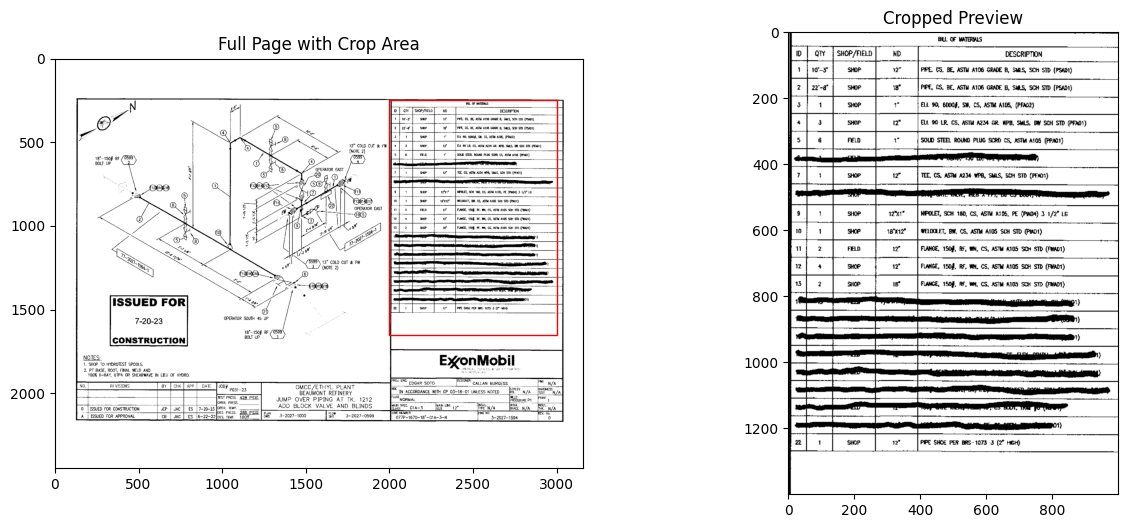


Is this crop okay?
1. Accept crop
2. Try again
Saved cropped image to: processed_pages/page_3.png

No items were extracted from the PDF.

Processed images have been saved to the 'processed_pages' directory
Both original crops and processed versions are saved for comparison.


In [1]:
import fitz
import pytesseract
from PIL import Image
import io
import cv2
import numpy as np
import re
import matplotlib.pyplot as plt
import os

class PDFProcessor:
    def __init__(self):
        self.current_page = None
        self.current_image = None
        self.crop_coords = {}
        self.output_dir = "processed_pages"
        
    def show_page_with_grid(self, image, page_num):
        """Display a page with grid overlay and coordinate tracking"""
        self.current_page = page_num
        self.current_image = image
        
        width, height = image.size
        
        while True:
            # Create figure and plot image
            fig, ax = plt.subplots(figsize=(15, 10))
            ax.imshow(image)
            
            # Add grid
            ax.grid(True, color='red', alpha=0.3)
            
            # Add major grid lines every 100 pixels
            major_x_ticks = np.arange(0, width, 100)
            major_y_ticks = np.arange(0, height, 100)
            ax.set_xticks(major_x_ticks)
            ax.set_yticks(major_y_ticks)
            
            # Add labels
            plt.title(f"Page {page_num + 1} - Move mouse to see coordinates\nDimensions: {width}x{height}")
            
            # Add coordinate display
            coord_text = ax.text(0.02, 0.98, '', transform=ax.transAxes, 
                               bbox=dict(facecolor='white', alpha=0.8),
                               verticalalignment='top')
            
            def mouse_move(event):
                if event.inaxes:
                    x, y = int(event.xdata), int(event.ydata)
                    coord_text.set_text(f'Coordinates: x={x}, y={y}')
                    plt.draw()
            
            fig.canvas.mpl_connect('motion_notify_event', mouse_move)
            
            plt.show()
            
            print("\nOptions:")
            print("1. Enter crop coordinates")
            print("2. Skip this page")
            print("3. Show grid view again")
            choice = input("Enter your choice (1, 2, or 3): ")
            
            if choice == "2":
                self.crop_coords[self.current_page] = None
                print(f"Skipping page {page_num + 1}")
                break
            elif choice == "3":
                continue
            elif choice == "1":
                try:
                    print("\nEnter coordinates for cropping:")
                    print("Format: x1,y1,x2,y2 (top-left and bottom-right corners)")
                    coords_input = input("Coordinates: ")
                    x1, y1, x2, y2 = map(int, coords_input.split(','))
                    
                    # Ensure coordinates are within image bounds
                    x1 = max(0, min(x1, width))
                    x2 = max(0, min(x2, width))
                    y1 = max(0, min(y1, height))
                    y2 = max(0, min(y2, height))
                    
                    # Show crop preview
                    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
                    
                    # Show full image with crop rectangle
                    ax1.imshow(image)
                    rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red')
                    ax1.add_patch(rect)
                    ax1.set_title("Full Page with Crop Area")
                    
                    # Show cropped preview
                    cropped_preview = image.crop((x1, y1, x2, y2))
                    ax2.imshow(cropped_preview)
                    ax2.set_title("Cropped Preview")
                    
                    plt.show()
                    
                    print("\nIs this crop okay?")
                    print("1. Accept crop")
                    print("2. Try again")
                    confirm = input("Enter your choice (1 or 2): ")
                    
                    if confirm == "1":
                        self.crop_coords[self.current_page] = (x1, y1, x2, y2)
                        break
                    
                except ValueError:
                    print("Invalid coordinates format. Please try again.")
                    continue
                
    def process_pdf(self, pdf_path):
        """Process PDF with user interaction for cropping"""
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)
            
        doc = fitz.open(pdf_path)
        all_items = []
        
        for page_num in range(len(doc)):
            page = doc[page_num]
            
            # Increase the resolution of the rendered page
            zoom = 4  # Increased zoom factor for better resolution
            mat = fitz.Matrix(zoom, zoom)
            pix = page.get_pixmap(matrix=mat, alpha=False)
            
            # Convert PyMuPDF pixmap to PIL Image
            img_data = pix.samples
            img = Image.frombytes("RGB", [pix.width, pix.height], img_data)
            
            # Show page and get user crop selection
            print(f"\nProcessing page {page_num + 1}")
            self.show_page_with_grid(img, page_num)
            
            if self.crop_coords.get(page_num) is None:
                print(f"Skipping page {page_num + 1}")
                continue
                
            # Scale crop coordinates according to zoom factor
            x1, y1, x2, y2 = [int(coord) for coord in self.crop_coords[page_num]]
            cropped_img = img.crop((x1, y1, x2, y2))
            
            # Save cropped image with high DPI
            output_path = os.path.join(self.output_dir, f'page_{page_num + 1}.png')
            cropped_img.save(output_path, dpi=(300, 300))
            print(f"Saved cropped image to: {output_path}")
            
            # Enhanced preprocessing for better OCR
            processed_img = self.preprocess_image(cropped_img)
            
            # Save processed image for verification
            processed_path = os.path.join(self.output_dir, f'page_{page_num + 1}_processed.png')
            processed_img.save(processed_path, dpi=(300, 300))
            
            # Perform OCR with improved settings
            custom_config = r'--oem 3 --psm 6 -c tessedit_char_whitelist=0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ/\"\\-. '
            text = pytesseract.image_to_string(processed_img, config=custom_config)
            
            # Extract and store BOM data
            items = self.extract_bom_data(text)
            all_items.extend(items)
        
        doc.close()
        return all_items
    
    @staticmethod
    def preprocess_image(image):
        """Enhanced preprocessing for better text clarity"""
        # Convert to OpenCV format
        opencv_img = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)
        
        # Convert to grayscale
        gray = cv2.cvtColor(opencv_img, cv2.COLOR_BGR2GRAY)
        
        # Apply adaptive thresholding
        binary = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            11,  # Block size
            2    # C constant
        )
        
        # Denoise
        denoised = cv2.fastNlMeansDenoising(binary)
        
        # Optional: Apply slight sharpening
        kernel = np.array([[-1,-1,-1],
                         [-1, 9,-1],
                         [-1,-1,-1]])
        sharpened = cv2.filter2D(denoised, -1, kernel)
        
        return Image.fromarray(sharpened)
    
    @staticmethod
    def extract_bom_data(text):
        """Extract Bill of Materials data"""
        items = []
        lines = [line.strip() for line in text.split('\n') if line.strip()]
        
        pattern = r'(?P<id>\d+)\s*(?P<qty>[\d\'-]+)\s*(?P<location>SHOP|FIELD)\s*(?P<nd>[\d/]+\"?)\s*(?P<description>.*)'
        
        for line in lines:
            match = re.search(pattern, line)
            if match:
                items.append({
                    'id': match.group('id'),
                    'qty': match.group('qty'),
                    'location': match.group('location'),
                    'nd': match.group('nd'),
                    'description': match.group('description').strip()
                })
        
        return items

def display_results(items):
    """Display the BOM results in a table format"""
    if not items:
        print("\nNo items were extracted from the PDF.")
        return
        
    print("\nBill of Materials:")
    print("=" * 100)
    print(f"{'ID':<5}{'QTY':<10}{'SHOP/FIELD':<12}{'ND':<8}{'DESCRIPTION':<65}")
    print("-" * 100)
    
    for item in items:
        print(f"{item['id']:<5}{item['qty']:<10}{item['location']:<12}{item['nd']:<8}{item['description']:<65}")

def main():
    print("PDF Bill of Materials Processor")
    print("==============================")
    pdf_path = input("Enter the path to your PDF file: ")
    
    if not os.path.exists(pdf_path):
        print(f"Error: File not found at {pdf_path}")
        return
        
    try:
        processor = PDFProcessor()
        items = processor.process_pdf(pdf_path)
        display_results(items)
        
        print(f"\nProcessed images have been saved to the '{processor.output_dir}' directory")
        print("Both original crops and processed versions are saved for comparison.")
        
    except Exception as e:
        print(f"Error processing PDF: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()